In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute        import SimpleImputer, KNNImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,
                                   StandardScaler, MinMaxScaler,
                                   RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split
from scipy.ndimage           import gaussian_filter1d
from scipy.stats             import zscore
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay ,accuracy_score
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('wine_quality_merged.csv')
print(f'Shape: {df.shape}')
#data shows 6497 row and 13 columns
df

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [5]:
print("Duplicates: ",df.duplicated().sum())
print('Missing values: ')
print(df.isnull().sum())

Duplicates:  1177
Missing values: 
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


In [6]:
#dropping dups
df.drop_duplicates(inplace=True)

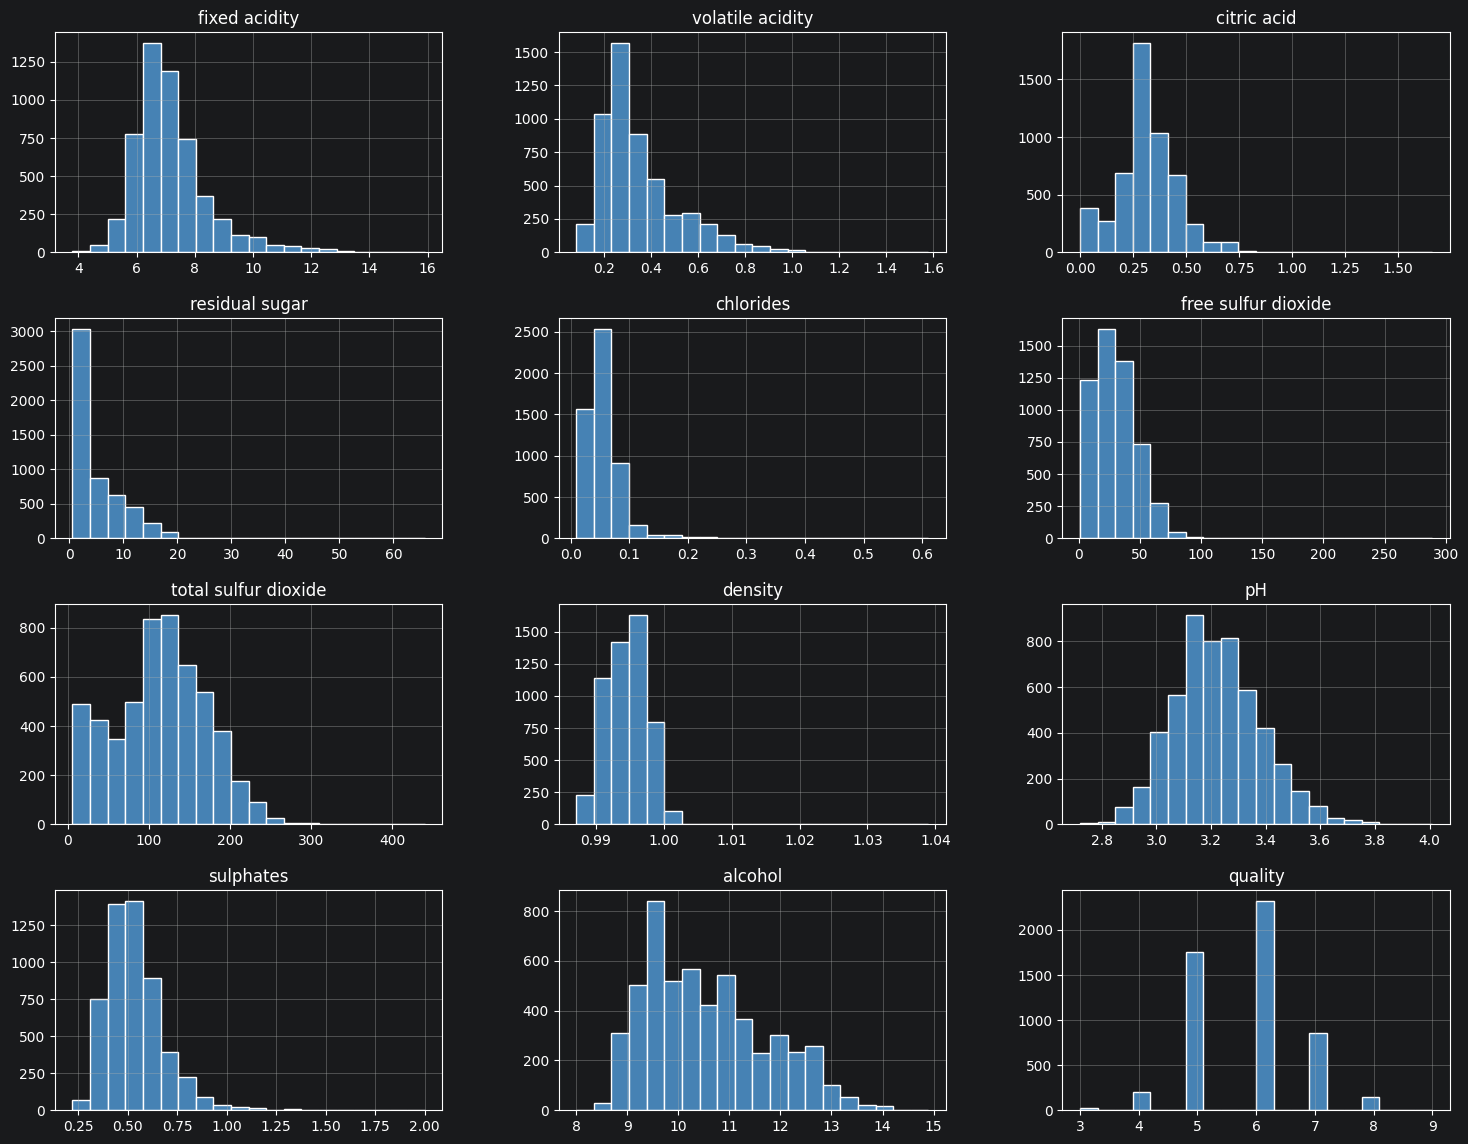

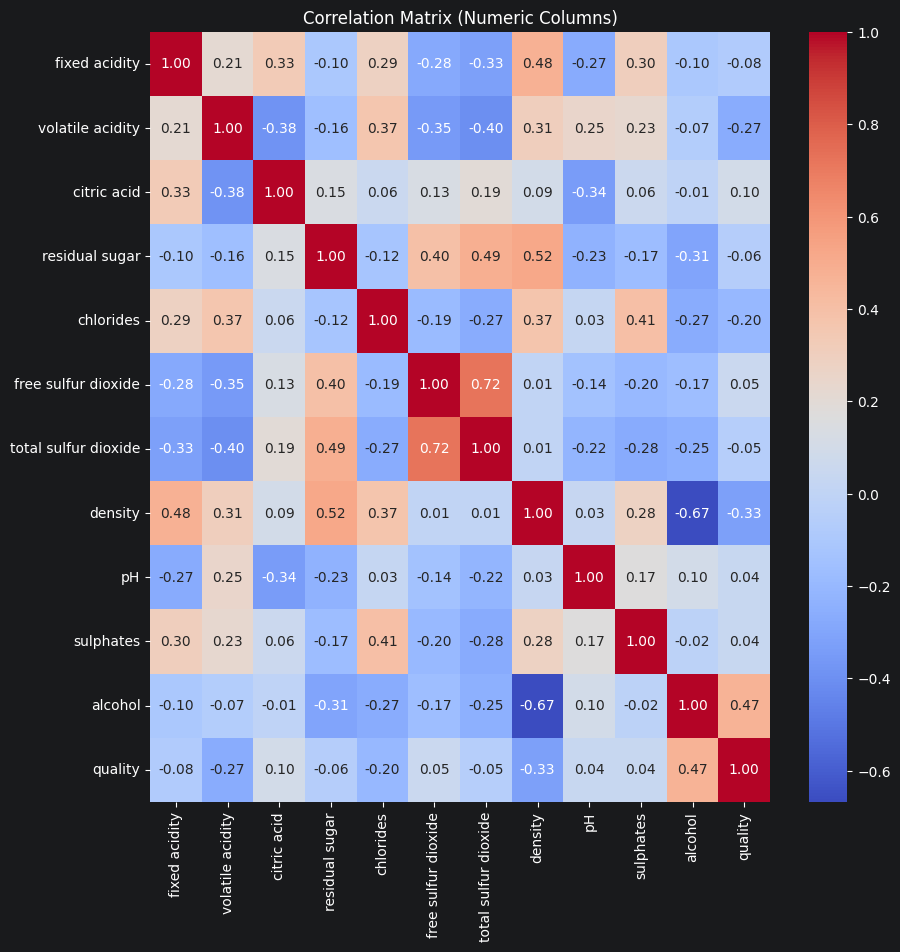

type: ['red', 'white'], 2


In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
obj_cols = df.select_dtypes(exclude=np.number).columns.tolist()
df[num_cols].hist(bins=20, figsize=(18, 14), color='steelblue', edgecolor='white')
plt.show()
# The cooreleation matrix (Heatmap)
plt.figure(figsize=(10, 10))
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Columns)")
plt.show()
for i in obj_cols:
    print(f"{i}: {df[i].unique().tolist()}, {len(df[i].unique())}")
# Check the distribution of the target variable


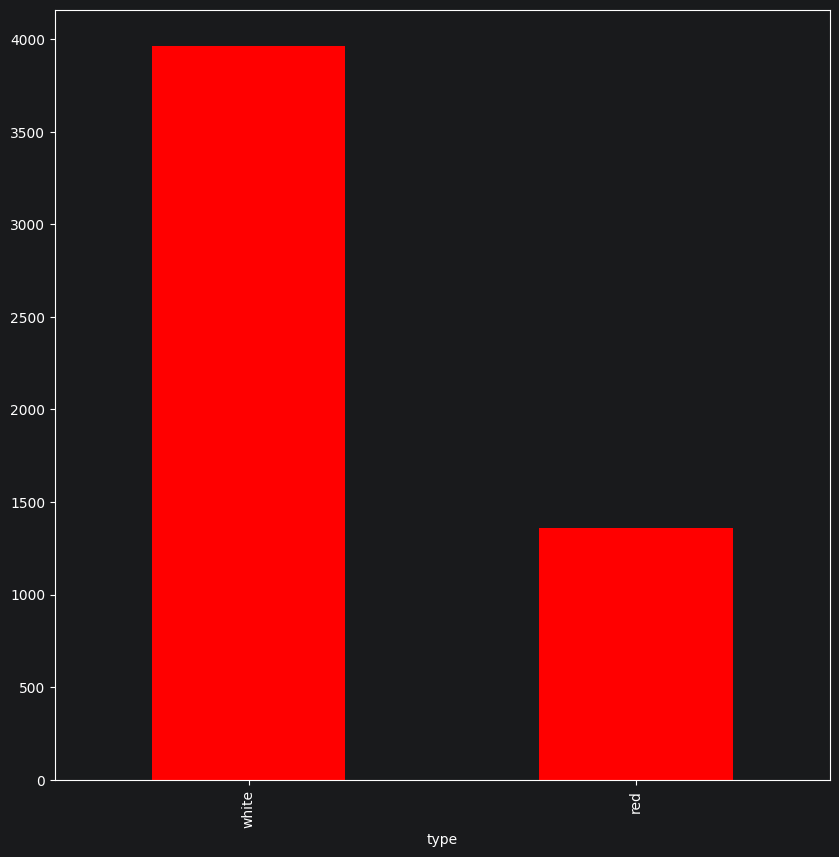

In [8]:
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    fig= plt.subplots(figsize=(10, 10))

    df[col].value_counts().plot.bar( color='red')


In [9]:
df['type_encoded'] = df['type'].map({'red': 0, 'white': 1})
X = df.drop(['type', 'type_encoded'], axis=1)
y = df['type_encoded']
x_train, x_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {x_train.shape} | Test: {x_test.shape}')

Train: (4256, 12) | Test: (1064, 12)


In [10]:
#
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [11]:
# 1. Calculate limits based on the training set
train_mean = x_train.mean()
train_std = x_train.std()

upper_limit = train_mean + 3 * train_std
lower_limit = train_mean - 3 * train_std

# 2. Clip the data
# values > upper_limit become the upper_limit
# values < lower_limit become the lower_limit
x_train_clipped = x_train.clip(lower=lower_limit, upper=upper_limit, axis=1)
x_test_clipped = x_test.clip(lower=lower_limit, upper=upper_limit, axis=1)

#### PCA finds directions of maximum variance in the data. If features are on different scales (For example, total sulfur dioxide ranges in the hundreds while pH ranges from 2–4), PCA will treat the high-magnitude feature as inherently more important — not because it carries more information, but simply because its numerical range is larger. Standardization (zero mean, unit variance) ensures every feature contributes equally, so PCA captures true structure rather than scale artifacts.

In [12]:
# Step 1: Fit PCA (compute mean + principal components)
def pca_fit(X, n_components):
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    cov_matrix = np.cov(X_centered, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # sort descending
    sorted_idx   = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[sorted_idx]
    eigenvectors = eigenvectors[:, sorted_idx]

    components              = eigenvectors[:, :n_components].T   # (k, n_features)
    explained_variance      = eigenvalues[:n_components]
    explained_variance_ratio = explained_variance / np.sum(eigenvalues)

    return mean, components, explained_variance, explained_variance_ratio


# Step 2: Transform data using fitted components
def pca_transform(X, mean, components):
    X_centered = X - mean
    return X_centered @ components.T                             # (n_samples, k)


# Step 3 (optional): Reconstruct back to original space
# def pca_inverse_transform(X_reduced, mean, components):
#     return X_reduced @ components + mean

In [13]:
# Fit on training data only
mean, components, explained_variance, explained_variance_ratio = pca_fit(x_train_scaled, n_components=10)

# Transform both splits using the same fitted parameters
X_train_pca = pca_transform(x_train_scaled, mean, components)
X_test_pca  = pca_transform(x_test_scaled,  mean, components)

print("Explained variance ratio:", explained_variance_ratio)
print(f"Cumulative variance:      {explained_variance_ratio.sum():.3f}")

Explained variance ratio: [0.25233387 0.21799658 0.14077496 0.08950474 0.07124889 0.05391102
 0.04579418 0.04234282 0.0396359  0.0248476 ]
Cumulative variance:      0.978


In [14]:
sk_pca = PCA(n_components=10)
X_train_sk = sk_pca.fit_transform(x_train_scaled)
X_test_sk  = sk_pca.transform(x_test_scaled)

# Compare outputs
print("Explained variance ratio (scratch):", explained_variance_ratio)
print("Explained variance ratio (sklearn): ", sk_pca.explained_variance_ratio_)

# Note: signs of components may be flipped — PCA eigenvectors have no unique sign
# So compare absolute values of projections
# print("\nMax difference in projections (abs):", np.max(np.abs(np.abs(X_train_pca) - np.abs(X_train_sk))))

Explained variance ratio (scratch): [0.25233387 0.21799658 0.14077496 0.08950474 0.07124889 0.05391102
 0.04579418 0.04234282 0.0396359  0.0248476 ]
Explained variance ratio (sklearn):  [0.25233387 0.21799658 0.14077496 0.08950474 0.07124889 0.05391102
 0.04579418 0.04234282 0.0396359  0.0248476 ]


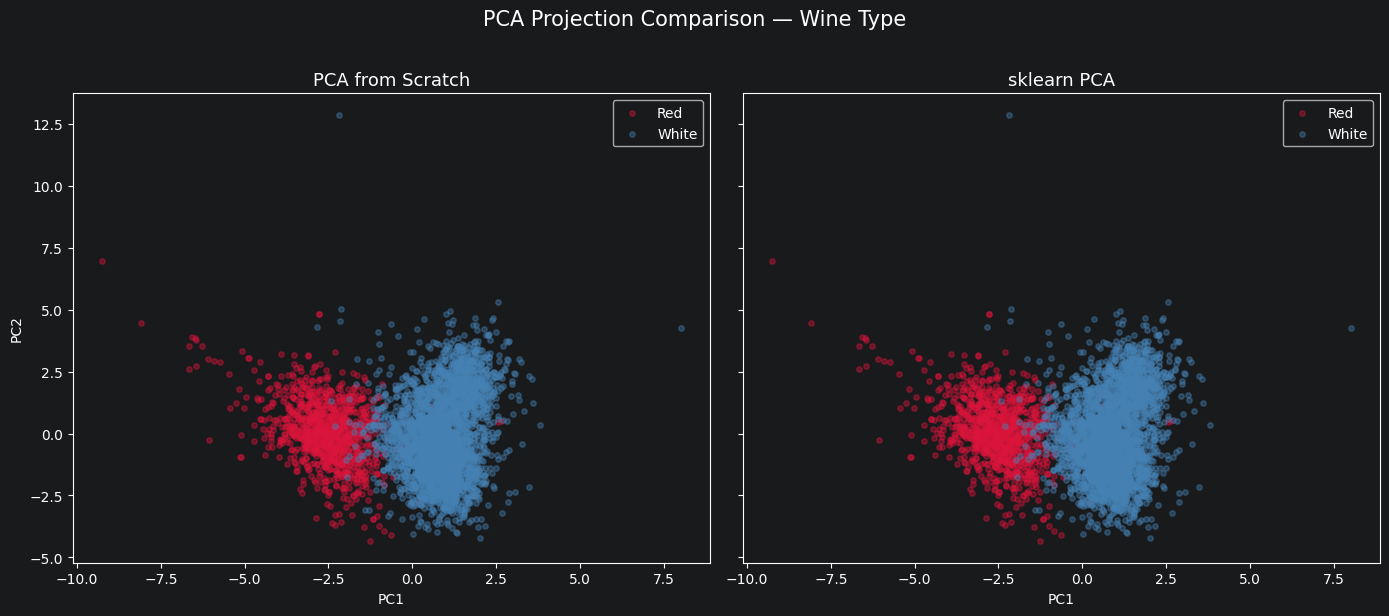

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

titles  = ['PCA from Scratch', 'sklearn PCA']
results = [X_train_pca, X_train_sk]

for ax, X_proj, title in zip(axes, results, titles):
    for label, color, name in [(0, 'crimson', 'Red'), (1, 'steelblue', 'White')]:
        mask = y_train.values == label
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                   c=color, label=name, alpha=0.4, s=15)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('PC1')
    ax.legend()

axes[0].set_ylabel('PC2')
fig.suptitle('PCA Projection Comparison — Wine Type', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

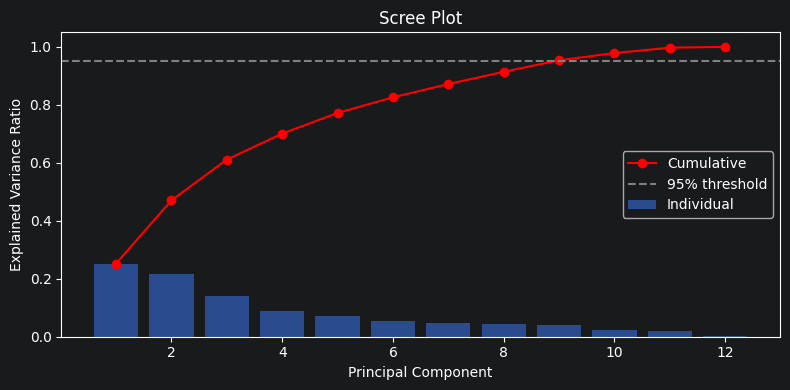

In [16]:
# Fit on all components to get the full variance breakdown
mean_full, components_full, _, evr_full = pca_fit(x_train_scaled, n_components=x_train_scaled.shape[1])

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(evr_full)+1), evr_full, alpha=0.6, label='Individual')
plt.plot(range(1, len(evr_full)+1), np.cumsum(evr_full), marker='o', color='red', label='Cumulative')
plt.axhline(0.95, color='gray', linestyle='--', label='95% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.legend()
plt.tight_layout()
plt.show()

# LDA

In [17]:
# mean calc
def calc_mean(X):
    return np.mean(X, axis=0)

# center data
def calc_x(X, mean):
    return X - mean

# scatter matrix
def calc_S(X_centered):
    return X_centered.T @ X_centered

# SW total calc
def calc_SW(S1, S2):
    SW = S1 + S2
    SW_inverse = np.linalg.pinv(SW)
    return SW_inverse

# W calc
def calc_W(SW_inverse, mu1, mu2):
    W = SW_inverse @ (mu1 - mu2)
    return W

# Normalization
def Normalization(W):
    return W / np.linalg.norm(W)

# data projection
def projection(X, W):
    data_proj = X @ W
    return data_proj

# sb calc
def calc_SB (mu1 , mu2) :
    mean_diff = np.array(mu1 - mu2).reshape(-1, 1)
    SB = mean_diff @ mean_diff.T
    return SB


# predection
def predict_lda(X_new, W, threshold, red_mean, white_mean):

    X_new = np.array(X_new)

    if X_new.ndim == 1:
        X_new = X_new.reshape(1, -1)

    X_new_lda = X_new @ W

    if red_mean < white_mean:
        predictions = np.where(X_new_lda < threshold, 0, 1)
    else:
        predictions = np.where(X_new_lda < threshold, 1, 0)

    return predictions

In [18]:
# Convert y to numpy arrays
y_train_array = y_train.values
y_test_array = y_test.values

# Split training data by class
X_train_red = x_train_clipped[y_train_array == 0]
X_train_white = x_train_clipped[y_train_array == 1]

# Calculate class means
mu_red = calc_mean(X_train_red)
mu_white = calc_mean(X_train_white)

# Center data
X_red_centered = calc_x(X_train_red, mu_red)
X_white_centered = calc_x(X_train_white, mu_white)

# Scatter matrices
S_red = calc_S(X_red_centered)
S_white = calc_S(X_white_centered)

# calculate SB
SB_cal = calc_SB(mu_red, mu_white )

# Within-class scatter inverse
SW_inverse = calc_SW(S_red, S_white)

# Weight vector
W = calc_W(SW_inverse, mu_red, mu_white)

# Normalize W
W = Normalization(W)

# Project train and test data
x_train_lda = projection(x_train_clipped, W)
x_test_lda = projection(x_test_clipped, W)

print("W shape:", W.shape)
print("Train LDA shape:", x_train_lda.shape)
print("Test LDA shape:", x_test_lda.shape)
print("SB:",SB_cal.shape)

W shape: (12,)
Train LDA shape: (4256,)
Test LDA shape: (1064,)
SB: (12, 12)


In [19]:
red_mean = np.mean(x_train_lda[y_train_array == 0])
white_mean = np.mean(x_train_lda[y_train_array == 1])

threshold = (red_mean + white_mean) / 2

if red_mean < white_mean:
    y_pred = np.where(x_test_lda < threshold, 0, 1)
else:
    y_pred = np.where(x_test_lda < threshold, 1, 0)

accuracy_Sc = accuracy_score(y_test_array, y_pred)

print("Red projected mean:", red_mean)
print("White projected mean:", white_mean)
print("Threshold:", threshold)
print("LDA Accuracy:", accuracy_Sc)

Red projected mean: 1.0008660385155976
White projected mean: 0.9947179860998465
Threshold: 0.9977920123077221
LDA Accuracy: 0.9962406015037594


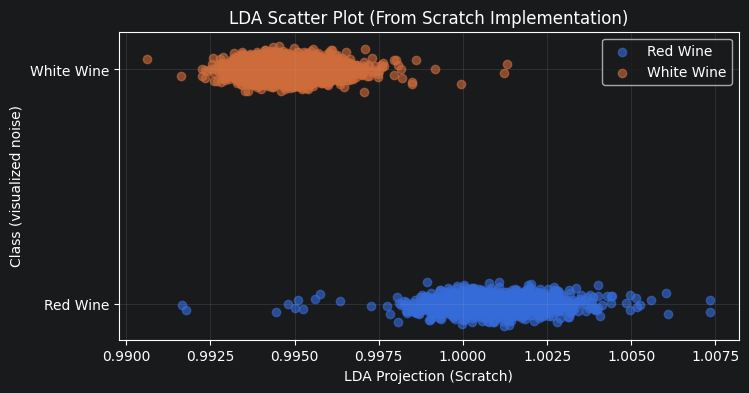

In [20]:
# Visualization for Scratch LDA

y_red = np.random.normal(0, 0.03, size=np.sum(y_train_array == 0))
y_white = np.random.normal(1, 0.03, size=np.sum(y_train_array == 1))

plt.figure(figsize=(8, 4))
plt.scatter(x_train_lda[y_train_array == 0],y_red,alpha=0.6,label='Red Wine')
plt.scatter(x_train_lda[y_train_array == 1],y_white,alpha=0.6,label='White Wine')

plt.xlabel("LDA Projection (Scratch)")
plt.ylabel("Class (visualized noise)")
plt.yticks([0, 1], ['Red Wine', 'White Wine'])
plt.title("LDA Scatter Plot (From Scratch Implementation)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [21]:
class0_mean = np.mean(x_train_lda[y_train_array == 0])
class1_mean = np.mean(x_train_lda[y_train_array == 1])

sample = x_test_clipped.iloc[0]
prediction = predict_lda(
    sample,
    W,
    threshold,
    red_mean,
    white_mean
)

print("Predictions:", y_pred[:20])
print("Accuracy:", accuracy_Sc)

if prediction[0] == 0:
    print("Predicted Type: Red Wine")
else:
    print("Predicted Type: White Wine")

Predictions: [1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0]
Accuracy: 0.9962406015037594
Predicted Type: White Wine


# LDA (library)

In [22]:
# sklearn LDA

sk_lda = LinearDiscriminantAnalysis()
sk_lda.fit(x_train_clipped, y_train_array)

# Project train & test data
x_train_lda_sk = sk_lda.transform(x_train_clipped)
x_test_lda_sk  = sk_lda.transform(x_test_clipped)

# Predictions & accuracy
y_pred_sk      = sk_lda.predict(x_test_clipped)
accuracy_sk = accuracy_score(y_test_array, y_pred_sk)

# Compare outputs
print("sklearn LDA Accuracy:", accuracy_sk)
print("Scratch LDA Accuracy:", accuracy_Sc)

sklearn LDA Accuracy: 0.9953007518796992
Scratch LDA Accuracy: 0.9962406015037594


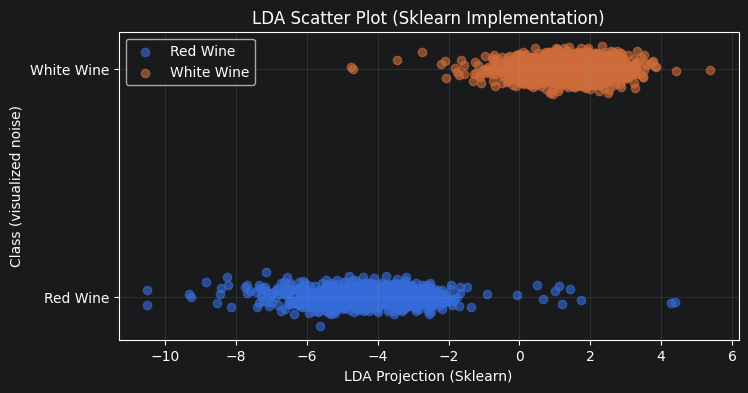

In [23]:
# Visualization for Sklearn LDA
y_red_sk = np.random.normal(0, 0.03, size=np.sum(y_train_array == 0))
y_white_sk = np.random.normal(1, 0.03, size=np.sum(y_train_array == 1))

plt.figure(figsize=(8, 4))
plt.scatter(x_train_lda_sk[y_train_array == 0],y_red_sk,alpha=0.6,label='Red Wine')
plt.scatter(x_train_lda_sk[y_train_array == 1],y_white_sk,alpha=0.6,label='White Wine')

plt.xlabel("LDA Projection (Sklearn)")
plt.ylabel("Class (visualized noise)")
plt.yticks([0, 1], ['Red Wine', 'White Wine'])
plt.title("LDA Scatter Plot (Sklearn Implementation)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

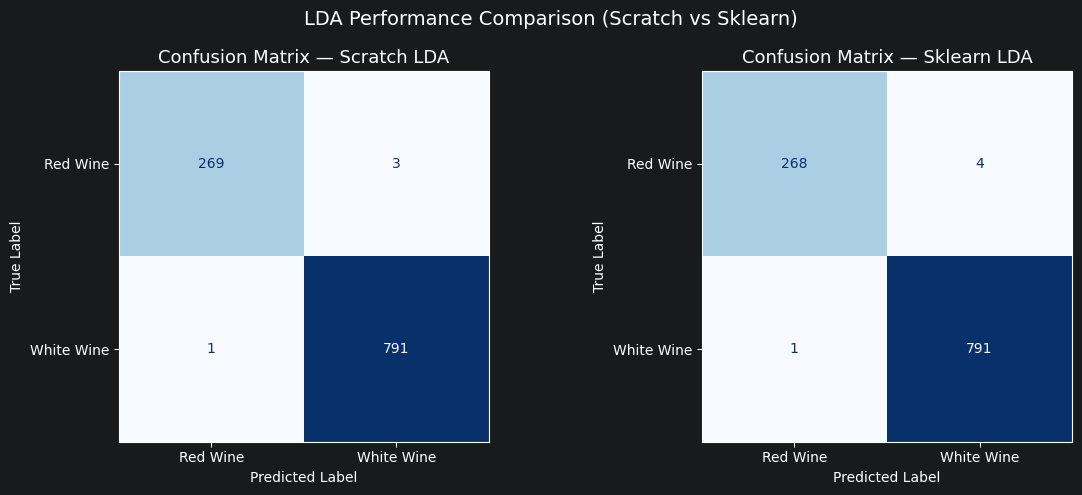

In [24]:
 # Confusion matrices side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [y_pred, y_pred_sk]
titles = ['Confusion Matrix — Scratch LDA', 'Confusion Matrix — Sklearn LDA']

for ax, preds, title in zip(axes, models, titles):
    cm = confusion_matrix(y_test_array, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Red Wine', 'White Wine'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("LDA Performance Comparison (Scratch vs Sklearn)", fontsize=14)
plt.tight_layout()
plt.show()

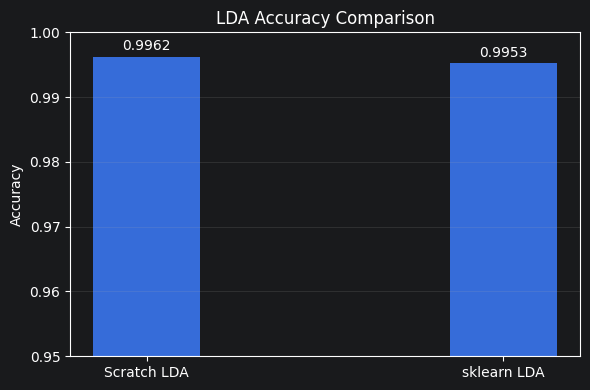

In [25]:
# Accuracy comparison bar chart
labels     = ['Scratch LDA', 'sklearn LDA']
accuracies = [accuracy_Sc, accuracy_sk]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, accuracies, width=0.3)
plt.ylim(0.95, 1.0)
plt.ylabel('Accuracy')
plt.title('LDA Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005, f'{acc:.4f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# SVM

#### using RBF because the data dosen't have a polynomial relationship, LDA is well separated which is more optimal for RBF

Accuracy: 0.9943609022556391


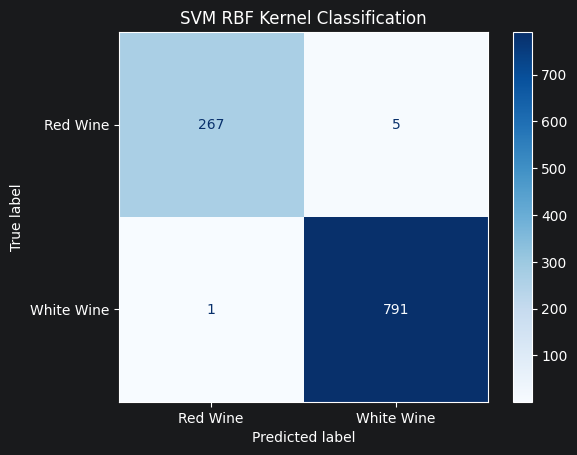

In [38]:
class svm():
    def __init__(self, x, xi, y_train, gemma=None, lr=0.001, epochs=1000, C=1.0):
        self.gemma   = gemma
        self.x       = np.array(x)
        self.xi      = np.array(xi)
        self.y_train = np.array(y_train)
        self.lr      = lr
        self.epochs  = epochs
        self.C       = C

        # if the user didn't provide a value for the gemma will calculates gemma =1/n*var(x)
        if gemma is None:
            self.gemma = 1 / (self.xi.shape[1] * self.xi.var())
        else:
            self.gemma = gemma
        # weights and bias over the kernel features
        self.w = np.zeros(self.xi.shape[0])
        self.b = 0.0

        # labels must be -1 or +1 for SVM
        self.y_train_ = np.where(self.y_train == 0, -1, 1)

    def rbf(self,x,xi):
        # K(x, xi) = exp(-gamma * ||x - xi||2)
        diff = x[:, None, :] - xi[None, :, :]
        sq_dist = np.sum(diff ** 2, axis=2)
        return np.exp(-self.gemma * sq_dist)

    def fit(self):
        # compute kernel matrix
        K = self.rbf(self.xi,self.xi)

        # Gradient Descent to optimize the predictions
        for i in range(self.epochs):
            scores = K @ self.w + self.b
            margin = self.y_train_ * scores
            mask = margin < 1
            dw = self.w - self.C * (self.y_train_ * mask) @ K
            db = -self.C * np.sum(self.y_train_ * mask)
            self.w -= self.lr * dw
            self.b -= self.lr * db



    def predict(self):
        K_test = self.rbf(self.x, self.xi)  # test vs train
        scores = K_test @ self.w + self.b
        return np.where(scores >= 0, 1, 0)

# svm model (RBF)
model_svm = svm(x_test_scaled, x_train_scaled, y_train)
model_svm.fit()
y_pred    = model_svm.predict()

# accuracy
accuracy_svm = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_svm)

# confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Red Wine', 'White Wine'])
disp.plot(cmap='Blues')
plt.title("SVM RBF Kernel Classification")
plt.show()

Sklearn SVM Accuracy: 0.9953


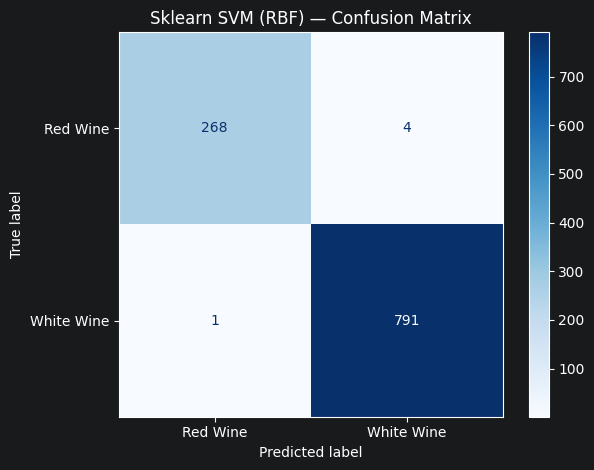

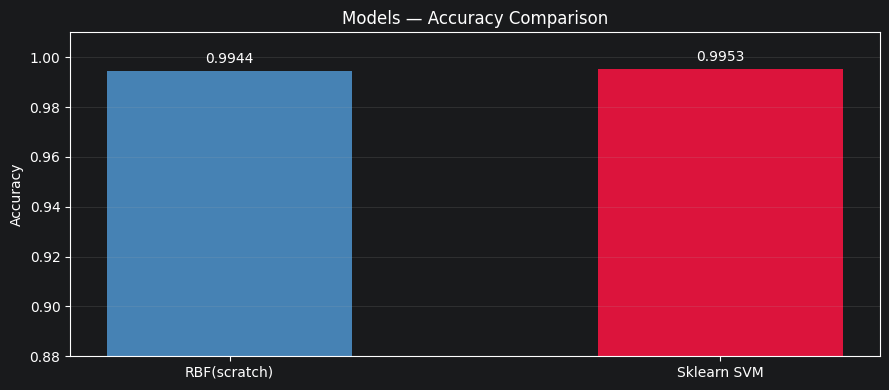

In [39]:
# train
sk_svm = SVC(kernel='rbf', gamma='scale', C=1.0)
sk_svm.fit(x_train_scaled, y_train)

# predict
y_pred_sk = sk_svm.predict(x_test_scaled)

# accuracy
acc_sk_svm = accuracy_score(y_test, y_pred_sk)
print(f"Sklearn SVM Accuracy: {acc_sk_svm:.4f}")

# confusion matrix
cm   = confusion_matrix(y_test, y_pred_sk)
disp = ConfusionMatrixDisplay(cm, display_labels=['Red Wine', 'White Wine'])
disp.plot(cmap='Blues')
plt.title("Sklearn SVM (RBF) — Confusion Matrix")
plt.tight_layout()
plt.show()

# compare SKlearn svm and from scratch svm
labels     = ['RBF(scratch)', 'Sklearn SVM']
accuracies = [accuracy_svm,    acc_sk_svm]

plt.figure(figsize=(9, 4))
bars = plt.bar(labels, accuracies, width=0.5,
               color=['steelblue', 'crimson'])
plt.ylim(0.88, 1.01)
plt.ylabel('Accuracy')
plt.title('Models — Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## Results

### Sklearn SVM Accuracy: 0.9953 | from scratch Accuracy: 0.9944
#### sklearn svm has 0.01% better accuracy than from scratch version